In [7]:
!pip install torch

   ---------------------------------------- 0.0/114.5 MB ? eta -:--:--
   ---------------------------------------- 0.1/114.5 MB 1.5 MB/s eta 0:01:16
   ---------------------------------------- 0.7/114.5 MB 8.8 MB/s eta 0:00:13
   ---------------------------------------- 0.9/114.5 MB 6.9 MB/s eta 0:00:17
   ---------------------------------------- 1.0/114.5 MB 6.0 MB/s eta 0:00:19
   ---------------------------------------- 1.1/114.5 MB 5.7 MB/s eta 0:00:21
   ---------------------------------------- 1.1/114.5 MB 5.7 MB/s eta 0:00:21
    --------------------------------------- 1.6/114.5 MB 4.9 MB/s eta 0:00:24
    --------------------------------------- 1.8/114.5 MB 4.8 MB/s eta 0:00:24
    --------------------------------------- 2.0/114.5 MB 4.7 MB/s eta 0:00:24
    --------------------------------------- 2.1/114.5 MB 4.7 MB/s eta 0:00:24
    --------------------------------------- 2.2/114.5 MB 4.6 MB/s eta 0:00:25
    --------------------------------------- 2.2/114.5 MB 4.6 MB/s eta 0

In [1]:
import torch
print(torch.__version__)

2.5.1


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Dataset_B.csv")

# FORWARD MODEL: geometry is input, modal features are output
input_cols  = ['r1','r2','r3','D1','D2','D3']   # X (input)
target_cols = [c for c in df.columns if c not in input_cols]  # Y (output)

X = df[input_cols].values    # geometry
Y = df[target_cols].values   # modal features

In [4]:
# Replace NaNs in Y with column means
col_means = np.nanmean(Y, axis=0)
inds = np.where(np.isnan(Y))
Y[inds] = np.take(col_means, inds[1])

# Remove zero variance columns in Y
stds = Y.std(axis=0)
mask = stds > 1e-12
Y = Y[:, mask]
target_cols = np.array(target_cols)[mask]

print("Input features:", X.shape[1])
print("Output features:", Y.shape[1])

Input features: 6
Output features: 20


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6216\2984001684.py:2: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(Y, axis=0)


In [5]:
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

Xn = scaler_X.fit_transform(X)
Yn = scaler_Y.fit_transform(Y)

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(
    Xn, Yn, test_size=0.2, random_state=42
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
Y_test_t  = torch.tensor(Y_test,  dtype=torch.float32)

print("Train size:", X_train_t.shape)
print("Test size:", X_test_t.shape)

Train size: torch.Size([3918, 6])
Test size: torch.Size([980, 6])


In [8]:
class ForwardNN(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, out_dim)
        )

    def forward(self, x):
        return self.net(x)

In [9]:
in_dim  = X_train.shape[1]   # 6
out_dim = Y_train.shape[1]   # modal features

model = ForwardNN(in_dim, out_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 500
best_loss = np.inf
best_model_state = model.state_dict()
loss_curve = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    y_pred = model(X_train_t)
    loss = criterion(y_pred, Y_train_t)

    if torch.isnan(loss):
        print("Loss became NaN, skipping")
        continue

    loss.backward()
    optimizer.step()
    loss_curve.append(loss.item())

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_model_state = model.state_dict()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

print("\nTraining complete. Best loss:", best_loss)
model.load_state_dict(best_model_state)

Epoch 0, Loss = 1.004333
Epoch 20, Loss = 0.276553
Epoch 40, Loss = 0.124549
Epoch 60, Loss = 0.086718
Epoch 80, Loss = 0.068900
Epoch 100, Loss = 0.057845
Epoch 120, Loss = 0.050242
Epoch 140, Loss = 0.044784
Epoch 160, Loss = 0.041595
Epoch 180, Loss = 0.037985
Epoch 200, Loss = 0.035581
Epoch 220, Loss = 0.033566
Epoch 240, Loss = 0.032267
Epoch 260, Loss = 0.030875
Epoch 280, Loss = 0.030271
Epoch 300, Loss = 0.028593
Epoch 320, Loss = 0.027709
Epoch 340, Loss = 0.026855
Epoch 360, Loss = 0.026935
Epoch 380, Loss = 0.025640
Epoch 400, Loss = 0.024873
Epoch 420, Loss = 0.024333
Epoch 440, Loss = 0.023900
Epoch 460, Loss = 0.023960
Epoch 480, Loss = 0.022964

Training complete. Best loss: 0.022298656404018402


<All keys matched successfully>

In [10]:
model.eval()
with torch.no_grad():
    Y_pred_t = model(X_test_t).cpu().numpy()

Y_pred = scaler_Y.inverse_transform(Y_pred_t)
Y_true = scaler_Y.inverse_transform(Y_test)

# Show R2 for first 6 modal features
for i in range(6):
    r2 = r2_score(Y_true[:, i], Y_pred[:, i])
    print(f"Modal feature {target_cols[i]}: R²={r2:.4f}")

Modal feature neff_01: R²=0.9982
Modal feature group_delay_01: R²=0.9956
Modal feature MFD_01: R²=0.9677
Modal feature neff_02: R²=0.9981
Modal feature group_delay_02: R²=0.9939
Modal feature MFD_02: R²=0.9806


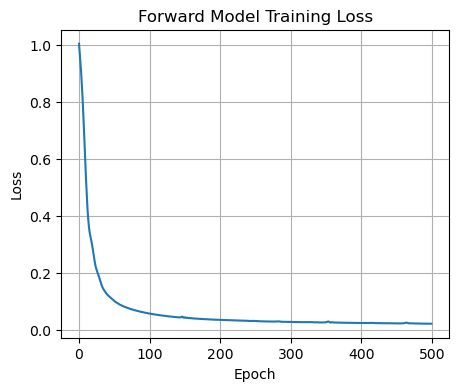

In [11]:
plt.figure(figsize=(5,4))
plt.plot(loss_curve)
plt.title("Forward Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [12]:
np.save("true_forward_FFNN.npy", Y_true)
np.save("pred_forward_FFNN.npy", Y_pred)
print("Saved!")

Saved!
